<a href="https://colab.research.google.com/github/jainlavanya14/Citation_Intent_Classification/blob/main/GenDLproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from datasets import load_dataset
dataset = load_dataset("kejian/MultiCite-classification-gold-context")


In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'x', 'y'],
        num_rows: 5491
    })
    test: Dataset({
        features: ['id', 'x', 'y'],
        num_rows: 3313
    })
    validation: Dataset({
        features: ['id', 'x', 'y'],
        num_rows: 2447
    })
})


In [ ]:
total = len(dataset['train']) + len(dataset['validation']) + len(dataset['test'])
print("Total instances:", total)


Total instances: 11251


In [ ]:
import pandas as pd

train_df = pd.DataFrame(dataset['train'])
test_df= pd.DataFrame(dataset['test'])
val_df = pd.DataFrame(dataset['validation'])

In [ ]:
print(train_df.columns)
print(train_df.head())


Index(['id', 'x', 'y'], dtype='object')
                                 id  \
0  021c423c731ecbe3e26b3ce234b390_0   
1  021c423c731ecbe3e26b3ce234b390_1   
2  021c423c731ecbe3e26b3ce234b390_2   
3  021e5dbe22bf0f4ebda4d37040d0a6_0   
4  021e5dbe22bf0f4ebda4d37040d0a6_1   

                                                   x                       y  
0  Automatic detection of fake from legitimate ne...              background  
1  Most previous systems built to identify fake n...              motivation  
2  A few recent studies have examined full articl...              background  
3  In the cross-lingual study of<cite> McDonald e...   motivation background  
4  We aim to do the same for syntactic dependenci...  differences background  


In [ ]:
print(train_df.isnull().sum())


id    0
x     0
y     0
dtype: int64


In [ ]:
train_df = train_df.dropna(subset=['x', 'y'])



In [ ]:
train_df['y'] = train_df['y'].apply(lambda x: x.split())


In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
labels_encoded = mlb.fit_transform(train_df['y'])

train_df['labels_encoded'] = list(labels_encoded)

print("Classes:", mlb.classes_)

Classes: ['background' 'differences' 'extends' 'future_work' 'motivation'
 'similarities' 'uses']


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'<cite>', '', text)  # remove citation tags
    return text.strip()

train_df['clean_text'] = train_df['x'].apply(clean_text)
test_df['clean_text'] = test_df['x'].apply(clean_text)
val_df['clean_text'] = val_df['x'].apply(clean_text)

In [ ]:
train_df = train_df.drop_duplicates(subset=['clean_text'])

In [ ]:
print(train_df.head())
print("Final dataset size:", train_df.shape)


                                 id  \
0  021c423c731ecbe3e26b3ce234b390_0   
1  021c423c731ecbe3e26b3ce234b390_1   
2  021c423c731ecbe3e26b3ce234b390_2   
3  021e5dbe22bf0f4ebda4d37040d0a6_0   
4  021e5dbe22bf0f4ebda4d37040d0a6_1   

                                                   x  \
0  Automatic detection of fake from legitimate ne...   
1  Most previous systems built to identify fake n...   
2  A few recent studies have examined full articl...   
3  In the cross-lingual study of<cite> McDonald e...   
4  We aim to do the same for syntactic dependenci...   

                           y         labels_encoded  \
0               [background]  [1, 0, 0, 0, 0, 0, 0]   
1               [motivation]  [0, 0, 0, 0, 1, 0, 0]   
2               [background]  [1, 0, 0, 0, 0, 0, 0]   
3   [motivation, background]  [1, 0, 0, 0, 1, 0, 0]   
4  [differences, background]  [1, 1, 0, 0, 0, 0, 0]   

                                          clean_text  
0  automatic detection of fake from legiti

In [ ]:
import pandas as pd

all_labels = [label for sublist in train_df['y'] for label in sublist]
intent_counts = pd.Series(all_labels).value_counts()

print(intent_counts)


background      2126
uses            1825
differences      829
similarities     607
motivation       428
extends          363
future_work       37
Name: count, dtype: int64


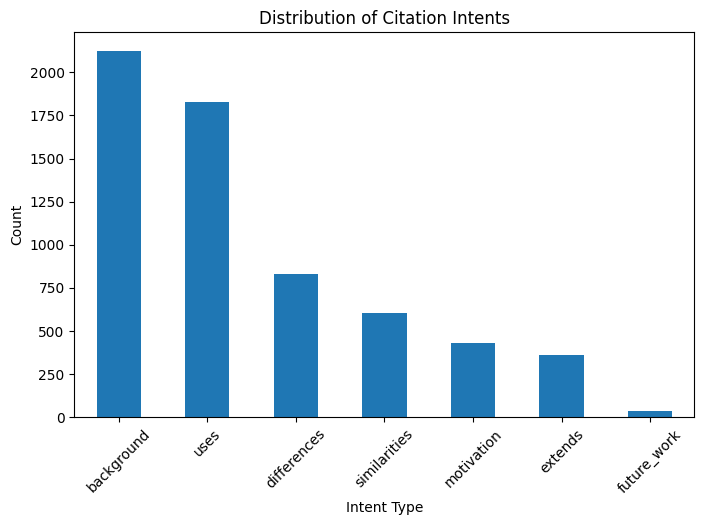

In [ ]:
import matplotlib.pyplot as plt

intent_counts.plot(kind='bar', figsize=(8,5))
plt.title("Distribution of Citation Intents")
plt.xlabel("Intent Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [ ]:
train_df['num_labels'] = train_df['y'].apply(len)

label_distribution = train_df['num_labels'].value_counts()
print(label_distribution)


num_labels
1    4706
2     707
3      29
4       2
Name: count, dtype: int64


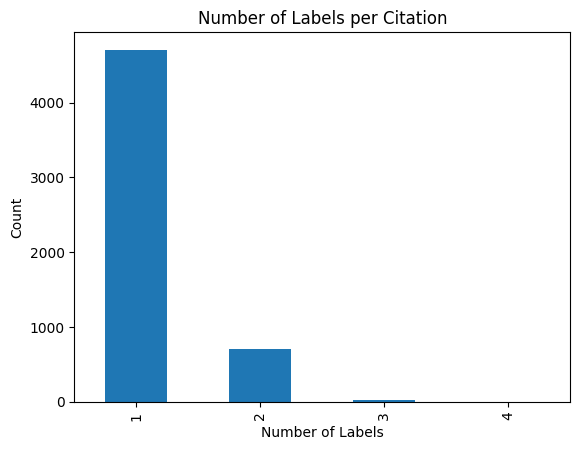

In [ ]:
label_distribution.plot(kind='bar')
plt.title("Number of Labels per Citation")
plt.xlabel("Number of Labels")
plt.ylabel("Count")
plt.show()


In [ ]:
train_df['text_length'] = train_df['clean_text'].apply(len)

print(train_df['text_length'].describe())


count    5444.000000
mean      238.802902
std       140.139707
min        35.000000
25%       149.000000
50%       203.000000
75%       288.000000
max      1741.000000
Name: text_length, dtype: float64


In [ ]:
train_df['word_count'] = train_df['clean_text'].apply(lambda x: len(x.split()))

print(train_df['word_count'].describe())


count    5444.000000
mean       37.392726
std        22.055532
min         3.000000
25%        23.000000
50%        32.000000
75%        45.000000
max       279.000000
Name: word_count, dtype: float64


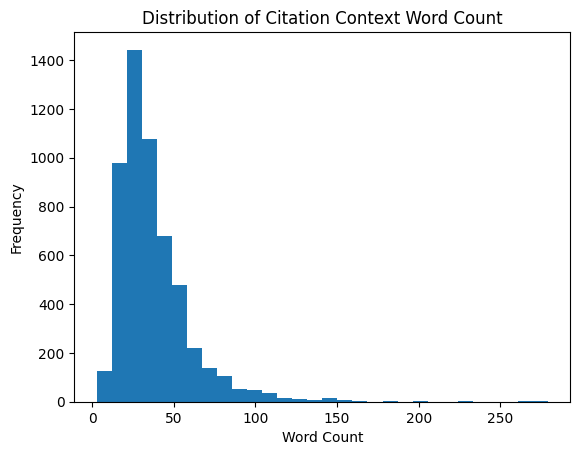

In [ ]:
plt.hist(train_df['word_count'], bins=30)
plt.title("Distribution of Citation Context Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()


In [ ]:

#most frequent words
from collections import Counter

all_words = " ".join(train_df['clean_text']).split()
word_freq = Counter(all_words)

print(word_freq.most_common(20))


[('the', 10864), ('and', 6212), ('of', 5214), ('et', 5077), ('in', 4161), ('to', 3838), ('a', 3288), ('al.,', 2995), ('we', 2665), ('for', 2276), ('.', 2101), ('al.', 2036), ('is', 2008), (',', 1919), ('as', 1813), ('on', 1755), ('that', 1617), ('with', 1513), ('by', 1480), ('our', 1218)]


ML Baselines :
TF-IDF + Logistic Regression,
TF-IDF + Random Forest,
TF-IDF + SVM

In [ ]:
import pandas as pd

train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

In [ ]:
for df in [train_df, val_df, test_df]:
    df['y'] = df['y'].apply(lambda x: x.split())

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
mlb.fit(train_df['y'])

train_df['labels_encoded'] = list(mlb.transform(train_df['y']))
val_df['labels_encoded'] = list(mlb.transform(val_df['y']))
test_df['labels_encoded'] = list(mlb.transform(test_df['y']))

print("Classes:", mlb.classes_)

Classes: ['background' 'differences' 'extends' 'future_work' 'motivation'
 'similarities' 'uses']


In [ ]:
#tf-idf

from sklearn.feature_extraction.text import TfidfVectorizer
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'<cite>', '', text)
    return text.strip()


for df_obj in [train_df, val_df, test_df]:
    if 'clean_text' not in df_obj.columns:
        df_obj['clean_text'] = df_obj['x'].apply(clean_text)

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train = vectorizer.fit_transform(train_df['clean_text'])
X_val = vectorizer.transform(val_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])

In [ ]:
print(train_df.columns)
print(val_df.columns)
print(test_df.columns)

Index(['id', 'x', 'y', 'labels_encoded', 'clean_text'], dtype='object')
Index(['id', 'x', 'y', 'labels_encoded', 'clean_text'], dtype='object')
Index(['id', 'x', 'y', 'labels_encoded', 'clean_text'], dtype='object')


In [ ]:
import numpy as np

y_train = np.array(train_df['labels_encoded'].tolist())
y_val = np.array(val_df['labels_encoded'].tolist())
y_test = np.array(test_df['labels_encoded'].tolist())

In [ ]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

model_lr = OneVsRestClassifier(
    LogisticRegression(max_iter=1000)
)

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [ ]:
#SVM
from sklearn.svm import LinearSVC

model_svm = OneVsRestClassifier(
    LinearSVC()
)

model_svm.fit(X_train, y_train)

y_pred_svm = model_svm.predict(X_test)

In [ ]:
#random forest
from sklearn.ensemble import RandomForestClassifier

model_rf = OneVsRestClassifier(
    RandomForestClassifier(n_estimators=100, random_state=42)
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [ ]:
from sklearn.metrics import f1_score, hamming_loss

def evaluate(y_true, y_pred, name):
    print(f"\n===== {name} =====")
    print("Micro F1:", f1_score(y_true, y_pred, average='micro'))
    print("Macro F1:", f1_score(y_true, y_pred, average='macro'))
    print("Hamming Loss:", hamming_loss(y_true, y_pred))

In [ ]:
evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_svm, "SVM")
evaluate(y_test, y_pred_rf, "Random Forest")


===== Logistic Regression =====
Micro F1: 0.3926640926640927
Macro F1: 0.16600590798629394
Hamming Loss: 0.1356560734767798

===== SVM =====
Micro F1: 0.5144916183612721
Macro F1: 0.35945438256181556
Hamming Loss: 0.13362942520805485

===== Random Forest =====
Micro F1: 0.41503084688726866
Macro F1: 0.25955725081252085
Hamming Loss: 0.13492303048596438


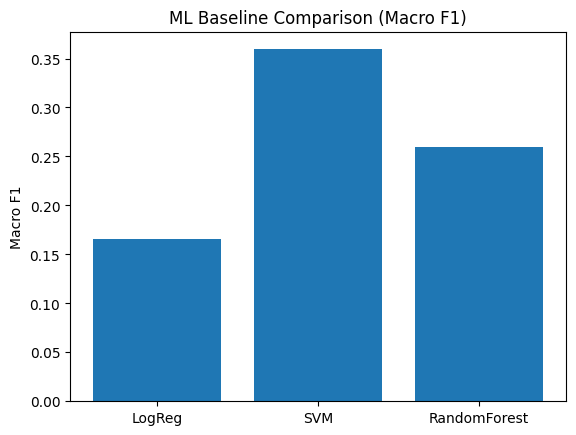

In [ ]:
import matplotlib.pyplot as plt

models = ["LogReg", "SVM", "RandomForest"]
macro_f1 = [
    f1_score(y_test, y_pred_lr, average='macro'),
    f1_score(y_test, y_pred_svm, average='macro'),
    f1_score(y_test, y_pred_rf, average='macro')
]

plt.bar(models, macro_f1)
plt.title("ML Baseline Comparison (Macro F1)")
plt.ylabel("Macro F1")
plt.show()

DL Models :
SciBERT + classifier head (fine-tuned),
Longformer + classifier head (fine-tuned),
BiLSTM + attention

In [ ]:
#BiLSTM + Attention
!pip install torch transformers datasets

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.metrics import f1_score
from tqdm import tqdm
import numpy as np

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
tokenizer = AutoTokenizer.from_pretrained("allenai/scibert_scivocab_uncased")

In [ ]:
class MultiCiteDataset(Dataset):
    def __init__(self, df, max_len=256):
        self.texts = df['clean_text'].tolist()
        self.labels = df['labels_encoded'].tolist()
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)
        }

In [ ]:
train_dataset = MultiCiteDataset(train_df)
val_dataset = MultiCiteDataset(val_df)
test_dataset = MultiCiteDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [ ]:
class BiLSTMAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_labels):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        # Attention Layer
        self.attention = nn.Linear(hidden_dim * 2, 1)

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids):

        x = self.embedding(input_ids)

        lstm_out, _ = self.lstm(x)
        # lstm_out shape: (batch, seq_len, hidden*2)

        # Attention scores
        attn_scores = self.attention(lstm_out)
        attn_scores = torch.softmax(attn_scores, dim=1)

        # Weighted sum
        context = torch.sum(attn_scores * lstm_out, dim=1)

        context = self.dropout(context)

        output = self.fc(context)

        return output

In [ ]:
model = BiLSTMAttention(
    vocab_size=tokenizer.vocab_size,
    embed_dim=128,
    hidden_dim=128,
    num_labels=len(mlb.classes_)
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

In [ ]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in tqdm(loader):
        input_ids = batch['input_ids'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].cpu().numpy()

            outputs = model(input_ids)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int().cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)

    micro = f1_score(all_labels, all_preds, average='micro')
    macro = f1_score(all_labels, all_preds, average='macro')

    return micro, macro

In [ ]:
num_epochs = 10
patience = 3   # early stopping patience
best_macro = 0
epochs_no_improve = 0

for epoch in range(num_epochs):

    train_loss = train_epoch(model, train_loader)
    val_micro, val_macro = evaluate(model, val_loader)

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Validation Micro F1: {val_micro:.4f}")
    print(f"Validation Macro F1: {val_macro:.4f}")

    # Check improvement
    if val_macro > best_macro:
        best_macro = val_macro
        torch.save(model.state_dict(), "best_bilstm_attention.pt")
        epochs_no_improve = 0
        print("✅ Best model saved!")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

    # Early stopping
    if epochs_no_improve >= patience:
        print("⛔ Early stopping triggered!")
        break

100%|██████████| 344/344 [00:20<00:00, 16.52it/s]



Epoch 1/10
Train Loss: 0.3510
Validation Micro F1: 0.5433
Validation Macro F1: 0.2376
✅ Best model saved!


100%|██████████| 344/344 [00:13<00:00, 26.14it/s]



Epoch 2/10
Train Loss: 0.2693
Validation Micro F1: 0.6030
Validation Macro F1: 0.3473
✅ Best model saved!


100%|██████████| 344/344 [00:13<00:00, 26.24it/s]


...


Epoch 8/10
Train Loss: 0.0464
Validation Micro F1: 0.6001
Validation Macro F1: 0.4946
✅ Best model saved!


100%|██████████| 344/344 [00:05<00:00, 60.29it/s]



Epoch 9/10
Train Loss: 0.0357
Validation Micro F1: 0.6061
Validation Macro F1: 0.4823
No improvement for 1 epoch(s)


100%|██████████| 344/344 [00:05<00:00, 61.14it/s]



Epoch 10/10
Train Loss: 0.0281
Validation Micro F1: 0.6057
Validation Macro F1: 0.4964
✅ Best model saved!


In [ ]:
model.load_state_dict(torch.load("best_bilstm_attention.pt"))

<All keys matched successfully>

In [ ]:
test_micro, test_macro = evaluate(model, test_loader)

print("\nFinal Test Performance")
print(f"Test Micro F1: {test_micro:.4f}")
print(f"Test Macro F1: {test_macro:.4f}")


Final Test Performance
Test Micro F1: 0.6235
Test Macro F1: 0.4709


Interpretation and Vizualization

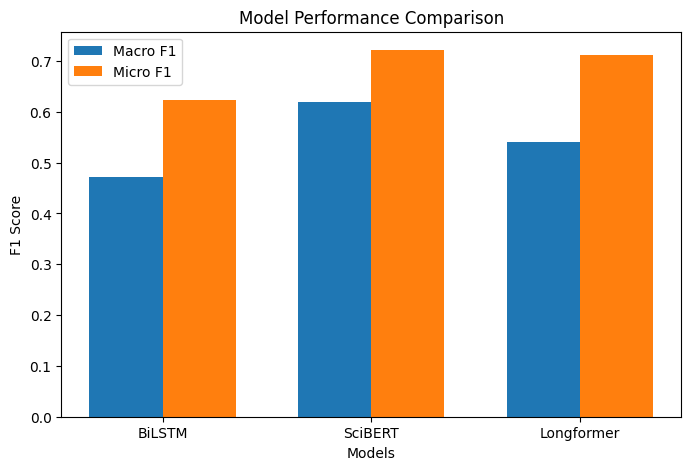

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["BiLSTM", "SciBERT", "Longformer"]

macro_f1 = [0.4709, 0.6198518377435284, 0.5398359950210511]   # replace with your results
micro_f1 = [0.6235, 0.7214428857715431, 0.71266936723006]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, macro_f1, width, label="Macro F1")
plt.bar(x + width/2, micro_f1, width, label="Micro F1")

plt.ylabel("F1 Score")
plt.xlabel("Models")
plt.title("Model Performance Comparison")

plt.xticks(x, models)

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["background","method","result","motivation"]   # change to your labels

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

NameError: name 'y_true' is not defined